<a href="https://colab.research.google.com/github/oktennant-del/CUNY---DC37--Data-Analytics-Academy/blob/main/nypd_arrest_data_python_project_3_april_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NYPD Arrest Datat Analytics - Python Project 3
This project analyzes NYPD arrest data from NYC Open Data. The goal is to compare arrest patterns between two ZIP codes and explore trends using descriptive statistics, data cleaning, and visualization.

Dataset source: https://opendata.cityofnewyork.us/

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
import pandas as pd
df = pd.read_excel('NYPD_Arrest_Data_(Year_to_Date)_20260411.xls')
df.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,299201470,2025-01-10,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
1,299351927,2025-01-13,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
2,299366743,2025-01-13,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823)
3,300990163,2025-02-12,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,2025-02-12,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)


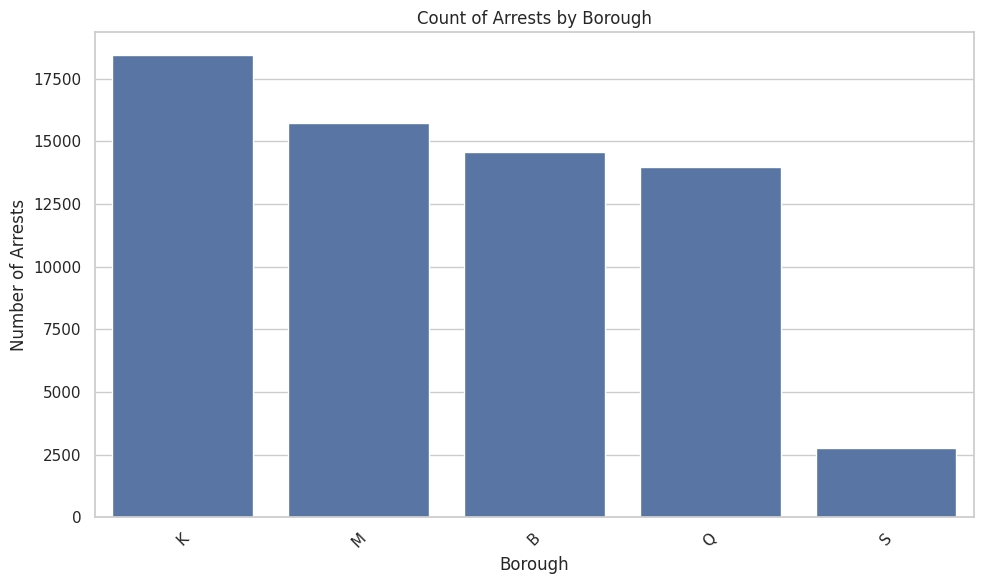

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='ARREST_BORO', order=df['ARREST_BORO'].value_counts().index)
plt.title('Count of Arrests by Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Arrests')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import os

# List all files and directories in the current folder
current_directory_contents = os.listdir('.')

print("Contents of the current directory:")
for item in current_directory_contents:
    print(item)

Contents of the current directory:
.config
NYPD_Arrest_Data_(Year_to_Date)_20260411.xls
sample_data


In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df = df.drop_duplicates()

df['arrest_precinct'] = df['arrest_precinct'].fillna("Unknown")
df['arrest_boro'] = df['arrest_boro'].fillna("Unknown")
# The column 'arrest_zip_code' does not exist in the DataFrame.
# Please verify the correct column name for zip codes in your dataset.
# df['arrest_zip_code'] = df['arrest_zip_code'].fillna("00000")

df.head()

,arrest_key,arrest_date,pd_cd,pd_desc,ky_cd,ofns_desc,law_code,law_cat_cd,arrest_boro,arrest_precinct,jurisdiction_code,age_group,perp_sex,perp_race,x_coord_cd,y_coord_cd,latitude,longitude,location
0,299201470,2025-01-10,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
1,299351927,2025-01-13,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
2,299366743,2025-01-13,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823)
3,300990163,2025-02-12,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,2025-02-12,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)


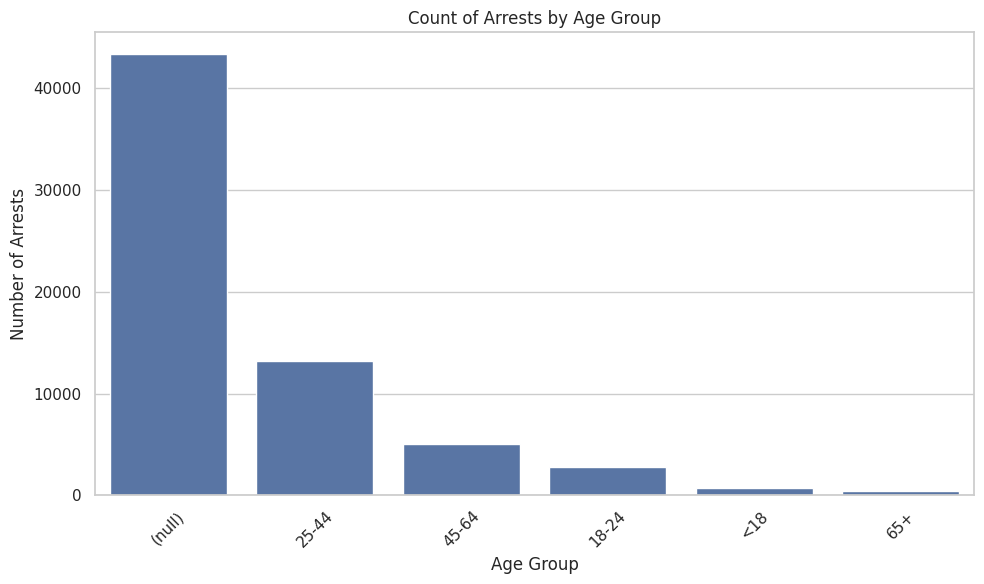

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='age_group', order=df['age_group'].value_counts().index)
plt.title('Count of Arrests by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Arrests')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

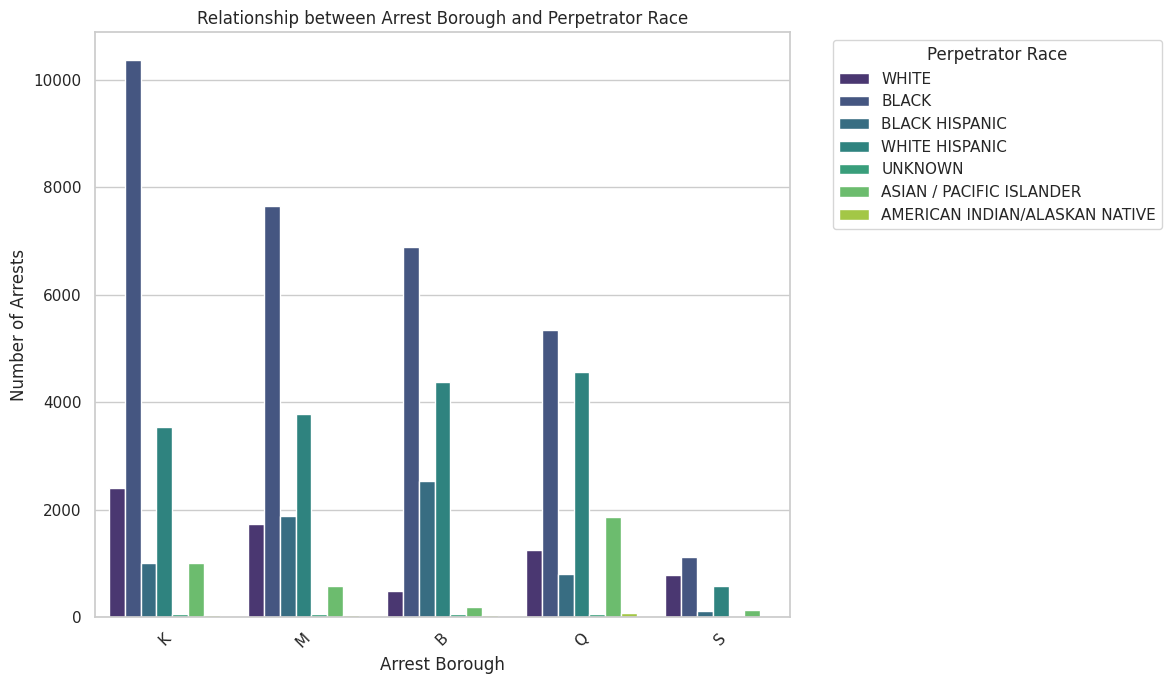

In [ ]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='arrest_boro', hue='perp_race', palette='viridis', order=df['arrest_boro'].value_counts().index)
plt.title('Relationship between Arrest Borough and Perpetrator Race')
plt.xlabel('Arrest Borough')
plt.ylabel('Number of Arrests')
plt.xticks(rotation=45)
plt.legend(title='Perpetrator Race', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
grouped_arrest_location = df.groupby('arrest_boro')[['latitude', 'longitude']].mean()
display(grouped_arrest_location)

,latitude,longitude
arrest_boro,,
B,40.840931,-73.891570
K,40.657547,-73.948821
M,40.772321,-73.971910
Q,40.714609,-73.830236
S,40.613304,-74.116485


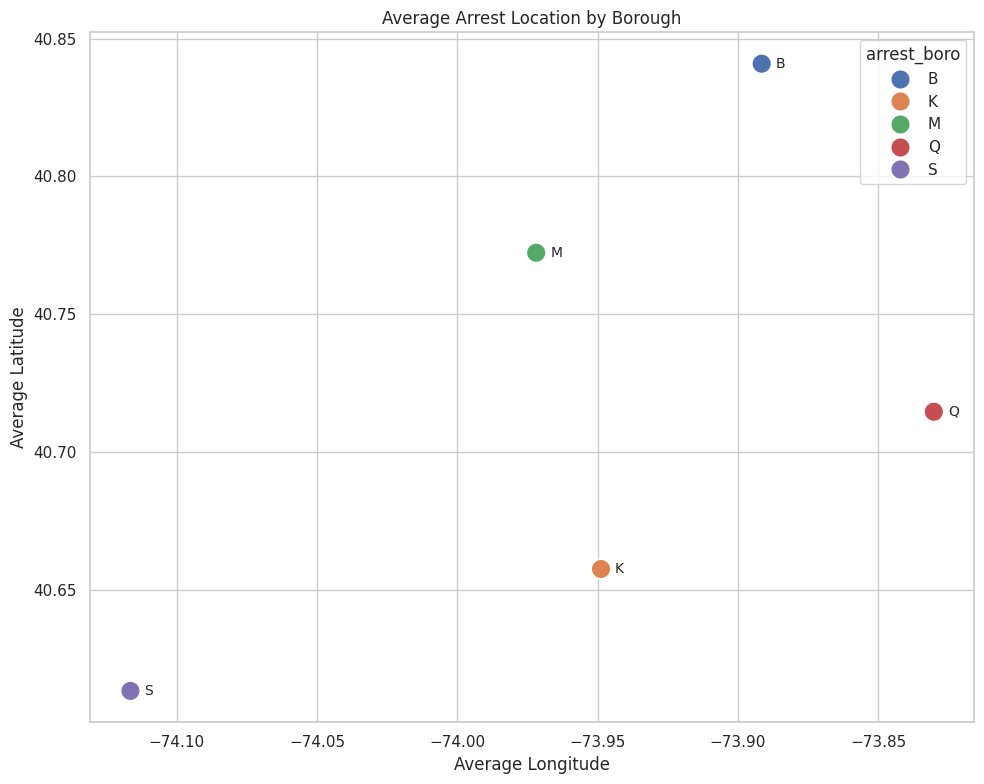

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=grouped_arrest_location, x='longitude', y='latitude', hue=grouped_arrest_location.index, s=200, palette='deep', legend='full')

for i, row in grouped_arrest_location.iterrows():
    plt.text(row['longitude'] + 0.005, row['latitude'], i, fontsize=10, ha='left', va='center')

plt.title('Average Arrest Location by Borough')
plt.xlabel('Average Longitude')
plt.ylabel('Average Latitude')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
missing_age_group = df['age_group'].isnull().sum()
print(f"Number of missing values in 'age_group' column: {missing_age_group}")

Number of missing values in 'age_group' column: 0


In [ ]:
arrests_by_age_group = df['age_group'].value_counts()
percentage_by_age_group = (arrests_by_age_group / len(df)) * 100
print("Percentage of total arrests by Age Group:")
display(percentage_by_age_group)

Percentage of total arrests by Age Group:


,count
age_group,
(null),66.150912
25-44,20.170901
45-64,7.737850
18-24,4.271000
<18,1.068132
65+,0.601205


In [ ]:
# Filter out '(null)' age_group records
df_filtered_age = df[df['age_group'] != '(null)']

# Recalculate arrests by age group on the filtered DataFrame
arrests_by_age_group_filtered = df_filtered_age['age_group'].value_counts()

# Recalculate percentage by age group on the filtered DataFrame
percentage_by_age_group_filtered = (arrests_by_age_group_filtered / len(df_filtered_age)) * 100

print("Percentage of total arrests by Age Group (excluding '(null)' records):")
display(percentage_by_age_group_filtered)

Percentage of total arrests by Age Group (excluding '(null)' records):


,count
age_group,
25-44,59.590678
45-64,22.859848
18-24,12.617770
<18,3.155570
65+,1.776135


In [ ]:
# Filter for 'PETIT LARCENY' offenses
petit_larceny_arrests = df_filtered_age[df_filtered_age['ofns_desc'] == 'PETIT LARCENY']

# Count 'PETIT LARCENY' arrests by age group
petit_larceny_by_age_group = petit_larceny_arrests['age_group'].value_counts()

# Get total arrests by age group (excluding '(null)' values)
total_arrests_by_age_group = df_filtered_age['age_group'].value_counts()

# Calculate the percentage of 'PETIT LARCENY' arrests for each age group
percentage_petit_larceny = (petit_larceny_by_age_group / total_arrests_by_age_group) * 100

print("Percentage of 'PETIT LARCENY' arrests for each age group (excluding '(null)' age group):")
display(percentage_petit_larceny.sort_values(ascending=False))

Percentage of 'PETIT LARCENY' arrests for each age group (excluding '(null)' age group):


,count
age_group,
45-64,20.311576
25-44,13.745367
65+,10.152284
18-24,7.895677
<18,2.571429


In [ ]:
# Filter data for age group 25-44
df_25_44 = df_filtered_age[df_filtered_age['age_group'] == '25-44']
most_common_offense_25_44 = df_25_44['ofns_desc'].mode()[0]
print(f"Most common offense for age group 25-44: {most_common_offense_25_44}")

# Filter data for age group 45-64
df_45_64 = df_filtered_age[df_filtered_age['age_group'] == '45-64']
most_common_offense_45_64 = df_45_64['ofns_desc'].mode()[0]
print(f"Most common offense for age group 45-64: {most_common_offense_45_64}")

Most common offense for age group 25-44: PETIT LARCENY
Most common offense for age group 45-64: PETIT LARCENY


In [ ]:
grouped_age_location = df_filtered_age[df_filtered_age['age_group'].isin(['25-44', '45-64'])].groupby('age_group')[['latitude', 'longitude']].mean()
display(grouped_age_location)

,latitude,longitude
age_group,,
25-44,40.732456,-73.922151
45-64,40.729154,-73.933726


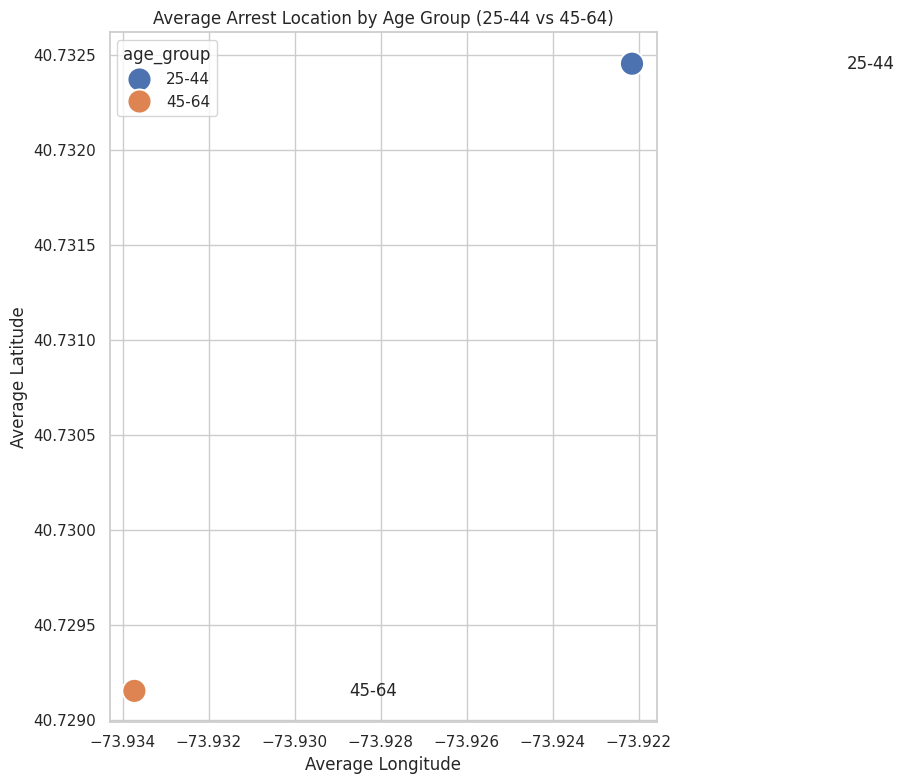

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=grouped_age_location, x='longitude', y='latitude', hue=grouped_age_location.index, s=300, palette='deep', legend='full')

for i, row in grouped_age_location.iterrows():
    plt.text(row['longitude'] + 0.005, row['latitude'], i, fontsize=12, ha='left', va='center')

plt.title('Average Arrest Location by Age Group (25-44 vs 45-64)')
plt.xlabel('Average Longitude')
plt.ylabel('Average Latitude')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
arrests_by_race = df['perp_race'].value_counts()
display(arrests_by_race)

,count
perp_race,
BLACK,31390
WHITE HISPANIC,16840
WHITE,6664
BLACK HISPANIC,6384
ASIAN / PACIFIC ISLANDER,3790
UNKNOWN,241
AMERICAN INDIAN/ALASKAN NATIVE,226


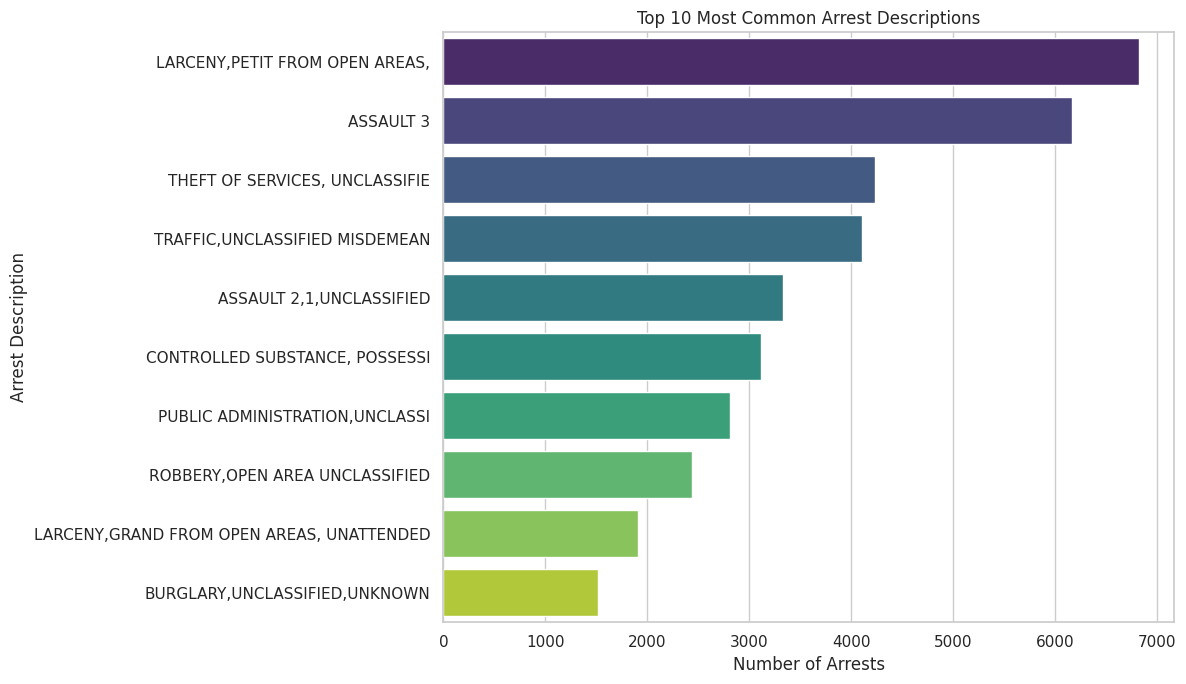

In [ ]:
top_10_arrest_descriptions = df['pd_desc'].value_counts().head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_arrest_descriptions.values, y=top_10_arrest_descriptions.index, hue=top_10_arrest_descriptions.index, palette='viridis', legend=False)
plt.title('Top 10 Most Common Arrest Descriptions')
plt.xlabel('Number of Arrests')
plt.ylabel('Arrest Description')
plt.tight_layout()
plt.show()

In [ ]:
prec1 = 28   # Harlem
prec2 = 75   # East New York

df_prec1 = df[df["arrest_precinct"] == prec1]
df_prec2 = df[df["arrest_precinct"] == prec2]

len(df_prec1), len(df_prec2)


(746, 2126)

In [ ]:
desc_stats = pd.DataFrame({
    "Precinct": [prec1, prec2],
    "Total Arrests": [len(df_prec1), len(df_prec2)],
    "Most Common Age Group": [
        df_prec1['age_group'].mode()[0],
        df_prec2['age_group'].mode()[0]
    ],
    "Most Common Offense": [
        df_prec1['ofns_desc'].mode()[0],
        df_prec2['ofns_desc'].mode()[0]
    ]
})

desc_stats


,Precinct,Total Arrests,Most Common Age Group,Most Common Offense
0,28,746,(null),PETIT LARCENY
1,75,2126,(null),DANGEROUS DRUGS


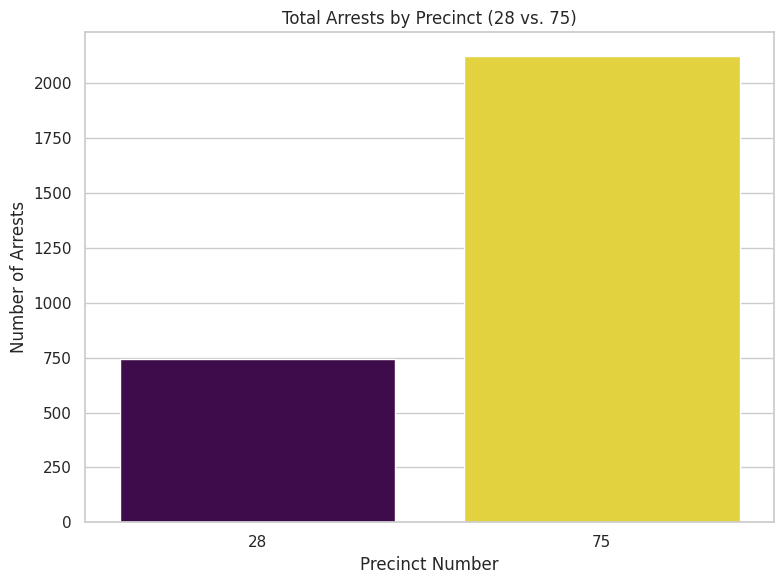

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Precinct', y='Total Arrests', data=desc_stats, hue='Precinct', palette='viridis', legend=False)
plt.title('Total Arrests by Precinct (28 vs. 75)')
plt.xlabel('Precinct Number')
plt.ylabel('Number of Arrests')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

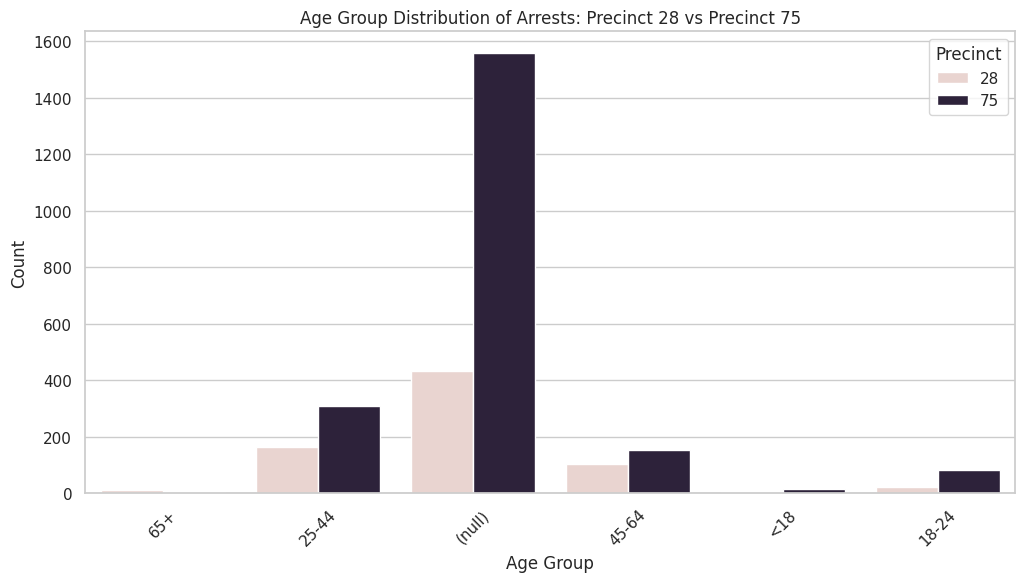

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(
    data=df[df["arrest_precinct"].isin([prec1, prec2])],
    x="age_group",
    hue="arrest_precinct"
)

plt.title("Age Group Distribution of Arrests: Precinct 28 vs Precinct 75")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Precinct")
plt.show()


/tmp/ipykernel_4923/3635679513.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_offenses_prec1.values, y=top_offenses_prec1.index, ax=axes[0], palette='Blues_r')
/tmp/ipykernel_4923/3635679513.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_offenses_prec2.values, y=top_offenses_prec2.index, ax=axes[1], palette='Greens_r')


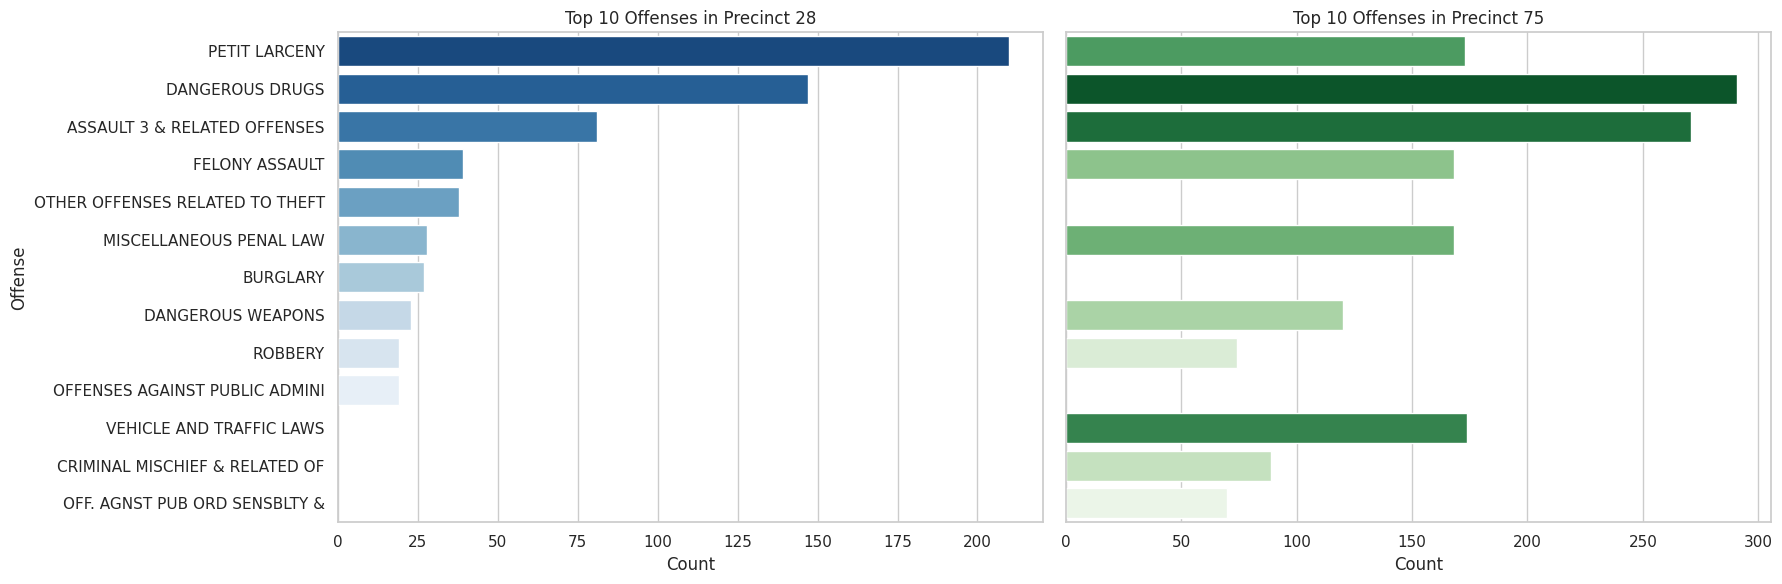

In [ ]:
top_offenses_prec1 = df_prec1['ofns_desc'].value_counts().head(10)
top_offenses_prec2 = df_prec2['ofns_desc'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(18,6), sharey=True)

sns.barplot(x=top_offenses_prec1.values, y=top_offenses_prec1.index, ax=axes[0], palette='Blues_r')
axes[0].set_title(f"Top 10 Offenses in Precinct {prec1}")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Offense")

sns.barplot(x=top_offenses_prec2.values, y=top_offenses_prec2.index, ax=axes[1], palette='Greens_r')
axes[1].set_title(f"Top 10 Offenses in Precinct {prec2}")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


##Comparsion of the most common offense between the 25-44 and 45-64 age groups:
##Both the 25-44 age group and the 45-64 age group share PETIT LARCENY as their most common offense.
##Comparsion of arrest locations of these two age groups on a map:
##The average coordinates for each age group are:latitude: 40.732456, longitude: -73.922151 (for age group 25-44) latitude: 40.729154, longitude: -73.933726 (for age group 45-64)
##The scatter plot titled 'Average Arrest Location by Age Group (25-44 vs 45-64)' visually represents these two points on a map, showing their relative average positions.
##Summary:
##Data Loading & Cleaning: Loaded the NYPD arrest data, cleaned column names, handled duplicate records, and filled missing values for arrest_precinct and arrest_boro.
##Exploratory Data Analysis (EDA): Explored arrest patterns across various dimensions:
1. Visualized arrest counts by borough.
2. Analyzed the distribution of arrests by age group.
3. Examined the relationship between arrest borough and perpetrator race.
4. Identified the top 10 most common arrest descriptions
5. Calculated and visualized the average arrest locations for each borough.
##Age Group Analysis: Found a significant number of (null) age group entries, but after filtering these out, I analyzed the percentage distribution of arrests by age group and determined that 'PETIT LARCENY' was the most common offense for both the '25-44' and '45-64' age groups. I also visualized the average arrest locations for these two age groups.
##Precinct Comparison: Compared arrest patterns between Precinct 28 (Harlem) and Precinct 75 (East New York), noting differences in total arrests, age group distribution, and the top 10 offenses in each precinct.
##This analysis provided insights into various aspects of NYPD arrest data, highlighting trends and geographical patterns.

### Conclusion

Precinct 28 (Harlem) and Precinct 75 (East New York) show distinct arrest patterns. Precinct 75 has a significantly higher number of arrests overall. Age group distributions differ between the two precincts, and the most common offenses vary, suggesting different policing patterns or neighborhood characteristics.

### Bias Discussion

Arrest data reflects policing activity, not necessarily underlying crime rates. Neighborhoods with heavier police presence may show higher arrest counts regardless of actual behavior. Demographic and socioeconomic factors influence both policing strategies and arrest outcomes. These limitations should be considered when interpreting results.
